# Caso real: scoring de crédito

**Tema:** Aprendizado Supervisionado › Regressão Logística

Um problema completo de classificação binária, com a classe positiva rara
(tema 3, módulo 5) e a preparação de dados feita dentro de um `Pipeline`
(tema 3, módulo 4) — do jeito que se faz em produção, não como formalidade.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
)

rng = np.random.default_rng(20)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Simulando um dataset de crédito com os defeitos usuais

In [2]:
n = 6000
idade = rng.normal(38, 11, n).clip(18, 75)
renda_anual = rng.lognormal(np.log(42000), 0.5, n)
n_atrasos_12m = rng.poisson(0.3, n)
tempo_emprego_anos = rng.exponential(4, n).clip(0, 40)
finalidade = rng.choice(["consumo", "reforma", "quitacao_dividas", "veiculo", "outro"],
                        n, p=[0.35, 0.15, 0.25, 0.20, 0.05])

logit = (-3.0 + 0.55 * n_atrasos_12m - 0.00002 * renda_anual
        - 0.05 * tempo_emprego_anos + 0.3 * (finalidade == "quitacao_dividas"))
prob = 1 / (1 + np.exp(-logit))
inadimplente = (rng.random(n) < prob).astype(int)

df = pd.DataFrame({
    "idade": idade.round(1), "renda_anual": renda_anual.round(2),
    "n_atrasos_12m": n_atrasos_12m, "tempo_emprego_anos": tempo_emprego_anos.round(1),
    "finalidade": finalidade, "inadimplente": inadimplente,
})
df.loc[rng.random(n) < 0.04, "renda_anual"] = np.nan  # nulos MCAR
print(f"shape: {df.shape}   taxa de inadimplência: {df['inadimplente'].mean():.2%}")
df.head()

shape: (6000, 6)   taxa de inadimplência: 2.48%


,idade,renda_anual,n_atrasos_12m,tempo_emprego_anos,finalidade,inadimplente
0,34.0,15845.82,0,2.6,outro,0
1,51.2,20693.47,0,6.5,quitacao_dividas,0
2,53.4,46165.43,0,2.2,quitacao_dividas,0
3,41.5,59915.86,0,10.2,veiculo,0
4,42.6,55280.67,1,0.3,consumo,1


## 2. Split, Pipeline e treino — sem vazamento

In [3]:
X = df.drop(columns="inadimplente")
y = df["inadimplente"]
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0)

colunas_numericas = ["idade", "renda_anual", "n_atrasos_12m", "tempo_emprego_anos"]
colunas_categoricas = ["finalidade"]

pre_processador = ColumnTransformer([
    ("num", Pipeline([("imputa", SimpleImputer(strategy="median")),
                      ("escalona", StandardScaler())]), colunas_numericas),
    ("cat", OneHotEncoder(drop="first"), colunas_categoricas),
])

pipeline = Pipeline([
    ("preparo", pre_processador),
    ("modelo", LogisticRegression(class_weight="balanced")),
])
pipeline.fit(X_treino, y_treino)

pred = pipeline.predict(X_teste)
probs = pipeline.predict_proba(X_teste)[:, 1]

print(f"precisão : {precision_score(y_teste, pred):.4f}")
print(f"recall   : {recall_score(y_teste, pred):.4f}")
print(f"F1       : {f1_score(y_teste, pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_teste, probs):.4f}")
print(f"PR-AUC   : {average_precision_score(y_teste, probs):.4f}")

precisão : 0.0479
recall   : 0.6889
F1       : 0.0896
ROC-AUC  : 0.6824
PR-AUC   : 0.0862


## 3. Comparando com e sem `class_weight="balanced"` (tema 3, módulo 5)

In [4]:
pipeline_sem_peso = Pipeline([
    ("preparo", pre_processador), ("modelo", LogisticRegression()),
])
pipeline_sem_peso.fit(X_treino, y_treino)
pred_sem_peso = pipeline_sem_peso.predict(X_teste)

print(f"{'estratégia':<24s} {'precisão':>10s} {'recall':>10s} {'F1':>10s}")
print("-" * 56)
print(f"{'sem peso de classe':<24s} {precision_score(y_teste, pred_sem_peso):>10.4f} "
      f"{recall_score(y_teste, pred_sem_peso):>10.4f} {f1_score(y_teste, pred_sem_peso):>10.4f}")
print(f"{'class_weight=balanced':<24s} {precision_score(y_teste, pred):>10.4f} "
      f"{recall_score(y_teste, pred):>10.4f} {f1_score(y_teste, pred):>10.4f}")

estratégia                 precisão     recall         F1
--------------------------------------------------------


sem peso de classe           0.0000     0.0000     0.0000


class_weight=balanced        0.0479     0.6889     0.0896


/home/leo/machine_learning/excercicios-machine-learning/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 4. Curvas ROC e Precisão-Recall lado a lado

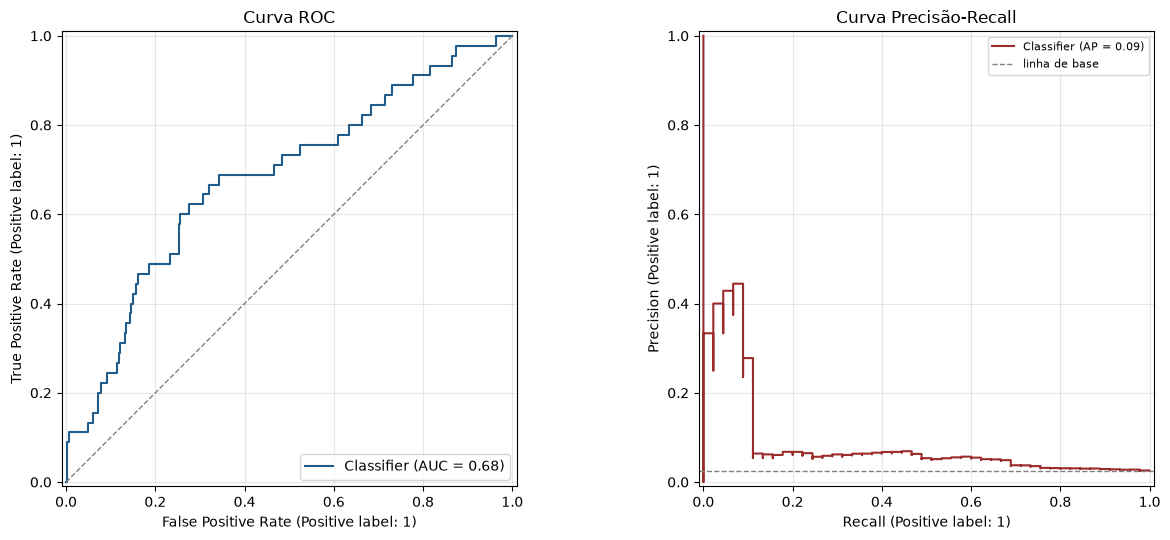

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
RocCurveDisplay.from_predictions(y_teste, probs, ax=axes[0], curve_kwargs={"color": AZUL})
axes[0].plot([0, 1], [0, 1], "--", color="gray", lw=1)
axes[0].set_title("Curva ROC")

PrecisionRecallDisplay.from_predictions(y_teste, probs, ax=axes[1],
                                        curve_kwargs={"color": VERMELHO})
axes[1].axhline(y_teste.mean(), color="gray", ls="--", lw=1, label="linha de base")
axes[1].set_title("Curva Precisão-Recall")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Interpretando o modelo final: odds ratio de cada feature

In [6]:
nomes_num = colunas_numericas
nomes_cat = list(pipeline.named_steps["preparo"]
                 .named_transformers_["cat"].get_feature_names_out(colunas_categoricas))
nomes_completos = nomes_num + nomes_cat
coeficientes = pipeline.named_steps["modelo"].coef_[0]

tabela_odds = pd.DataFrame({
    "coeficiente": coeficientes, "odds_ratio": np.exp(coeficientes),
}, index=nomes_completos).sort_values("odds_ratio", ascending=False)
print(tabela_odds.round(4).to_string())

print("\nleitura: odds_ratio > 1 aumenta a chance de inadimplência; < 1 diminui.")
print("Lembrete do notebook anterior: isso é sobre CHANCES, não diretamente")
print("sobre probabilidade — e os coeficientes numéricos estão em unidades")
print("de DESVIO-PADRÃO (features já padronizadas dentro do Pipeline).")

                             coeficiente  odds_ratio
finalidade_quitacao_dividas       0.4067      1.5018
n_atrasos_12m                     0.3867      1.4722
finalidade_reforma                0.1851      1.2034
tempo_emprego_anos               -0.0915      0.9125
idade                            -0.0946      0.9097
finalidade_outro                 -0.1485      0.8620
finalidade_veiculo               -0.1647      0.8482
renda_anual                      -0.3753      0.6871

leitura: odds_ratio > 1 aumenta a chance de inadimplência; < 1 diminui.
Lembrete do notebook anterior: isso é sobre CHANCES, não diretamente
sobre probabilidade — e os coeficientes numéricos estão em unidades
de DESVIO-PADRÃO (features já padronizadas dentro do Pipeline).


## 6. Validação cruzada: o número final a reportar

In [7]:
scores_auc = cross_val_score(pipeline, X, y, cv=5, scoring="roc_auc")
scores_pr_auc = cross_val_score(pipeline, X, y, cv=5, scoring="average_precision")
print(f"ROC-AUC (5-fold): {scores_auc.mean():.4f} ± {scores_auc.std():.4f}")
print(f"PR-AUC  (5-fold): {scores_pr_auc.mean():.4f} ± {scores_pr_auc.std():.4f}")

ROC-AUC (5-fold): 0.6508 ± 0.0415
PR-AUC  (5-fold): 0.0708 ± 0.0161


## O que levar deste notebook

- O fluxo completo — split, `Pipeline`, `class_weight`, métricas adequadas
  a classes desbalanceadas — é o que transforma um exercício de sala de
  aula num modelo que se sustentaria em produção.
- `class_weight="balanced"` tipicamente troca precisão por recall — a
  mesma troca vista no tema 3, agora dentro de um pipeline completo.
- Interpretar os coeficientes finais como odds ratio, sabendo que as
  features numéricas estão padronizadas, é o que transforma o modelo numa
  explicação de negócio, não só num número de desempenho.

→ Próximo: o notebook de **exercícios** do módulo.